<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 4 — Cluster Characterization</h3>
<p style="color:#D8C0B4; font-size:15px; margin-top:14px;">This notebook translates the final numerical cluster labels into interpretable customer segments using spend, behavioural, demographic, complaint and geographic profiles.</p>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports and data loading</li>
<li>Segment sizes</li>
<li>Spend profile</li>
<li>Behavioural and demographic profile</li>
<li>Loyalty, gender and household checks</li>
<li>Normalised comparison</li>
<li>Radar profile summary</li>
<li>Feature by feature plots</li>
<li>Main differentiators by cluster</li>
<li>Cluster interpretation and naming rationale</li>
<li>Geographic check</li>
<li>Final segment names</li>
<li>Export ID and cluster mapping</li>
</ol>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1) Imports and data loading</b></h2>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Characterization logic.</b><br><br>
This notebook does not change the clusters created in the modelling stage. Its purpose is to translate the numerical labels into meaningful customer groups. For that reason, every name is based on repeated evidence across spend, promotion behaviour, demographics, loyalty and service indicators.
</div>

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils_cluster_characterization as ucc

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = Path("../datasets")
df = ucc.load_characterization_data(DATA_DIR)
print("Characterization dataset shape:", df.shape)
df.head()

PROJECT_PALETTE = ['#B87540', '#B2543D', '#7E6A43', '#A8B7BA', '#D8C0B4', '#C8AB8C', '#5A3516', '#B98F70']
sns.set_theme(style='whitegrid', palette=PROJECT_PALETTE)

Characterization dataset shape: (33038, 42)


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2) Segment sizes</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The first check is the size of each segment. Very small clusters would require caution because they may represent niche behaviour or residual outlier structure rather than stable customer segments.</p>
</div>

,cluster,cluster_name,customers,share_%
0,0,Vegetarians,3733,11.3
1,1,Regulars,5040,15.3
2,2,Wellness,3324,10.1
3,3,Promoters,4290,13.0
4,4,Loyalists,3527,10.7
5,5,Families,3594,10.9
6,6,Economizers,6319,19.1
7,7,Techies,3211,9.7


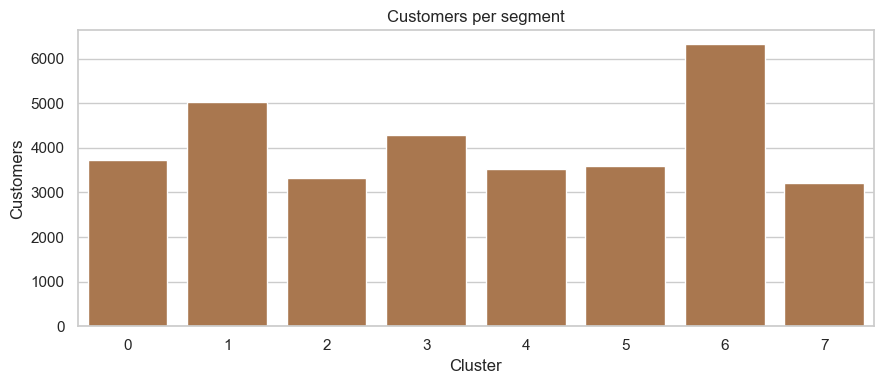

In [2]:
size_profile = ucc.cluster_sizes(df)
display(size_profile)
ucc.plot_cluster_sizes(size_profile)


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>3) Spend profile</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Absolute lifetime spend by category is used to understand the main purchasing orientation of each segment. These variables are kept in original units for interpretability.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why absolute spend is still useful here.</b><br><br>
The clustering model avoids giving too much weight to dominant variables, but the interpretation stage should still look at the real spending levels. Absolute spend helps identify whether a segment is commercially relevant, while the normalised comparison later shows which categories are most distinctive within each group.
</div>

,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood
cluster,,,,,,,,,,
0,10685.12,2018.70,2007.66,418.42,413.40,73.78,88.59,715.08,235.11,261.00
1,12717.89,1142.89,356.64,259.13,582.64,609.01,434.99,459.10,232.50,274.29
2,12203.49,830.64,1509.06,611.41,167.33,161.97,117.65,2017.04,150.78,415.06
3,12944.92,1094.65,403.71,243.39,412.34,721.19,422.52,483.59,226.61,304.49
4,29445.31,3125.53,336.12,715.60,707.88,1015.52,1002.84,1278.87,336.57,366.11
5,25231.13,4941.14,811.44,819.58,1517.47,1501.61,1333.31,916.69,430.20,362.59
6,17822.95,1234.29,523.12,336.19,357.44,794.14,675.33,748.60,227.30,396.00
7,9804.98,10586.03,181.42,561.49,1101.06,916.07,862.01,252.60,1455.50,301.81
OVERALL,16306.23,2764.28,727.34,464.35,622.00,723.87,608.12,820.55,374.29,336.24


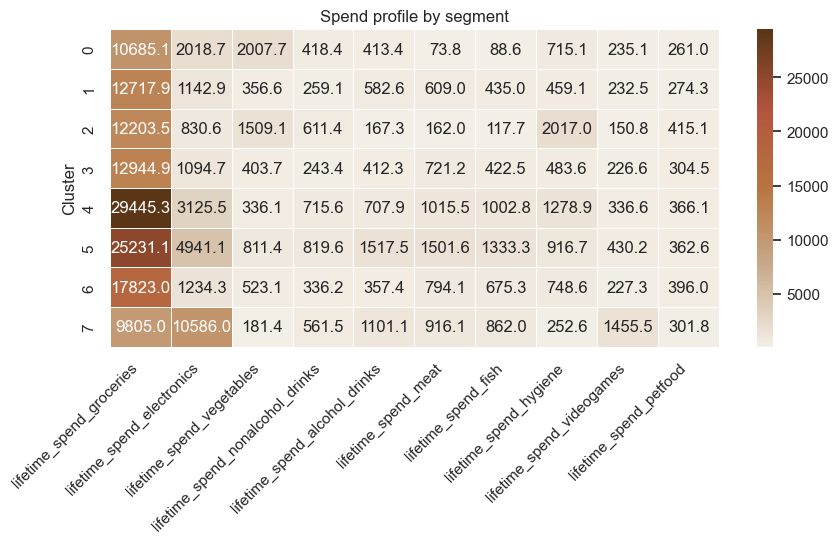

In [3]:
spend_cols = ucc.spend_columns(df)
spend_profile = ucc.profile_table(df, spend_cols)
display(spend_profile)
ucc.plot_profile_heatmap(spend_profile, "Spend profile by segment")

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>4) Behavioural and demographic profile</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">This table adds non spend variables such as promotion usage, product diversity, age, education, tenure, children and complaints. These variables are not all used to fit the clustering model, but they are essential to understand who the customers are and to assign defensible business names to the final segments.</p>
</div>

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,tenure,total_children,number_complaints,customer_loyalty_flag
cluster,,,,,,,,
0,9.80,0.11,3.20,83.83,11.52,1.92,0.78,0.58
1,9.73,0.48,3.66,112.81,9.27,1.54,1.11,0.48
2,9.82,0.17,3.57,121.74,9.74,1.89,0.57,0.59
3,9.70,0.86,3.71,93.89,9.97,1.43,1.03,0.64
4,10.53,0.49,3.93,238.02,13.56,1.99,1.10,0.77
5,10.64,0.21,3.26,295.46,13.16,5.41,0.92,0.68
6,10.01,0.17,2.54,152.73,12.09,1.59,0.74,0.63
7,10.50,0.26,1.51,113.48,9.09,0.64,1.06,0.49
OVERALL,10.05,0.35,3.17,148.91,11.06,1.99,0.91,0.60


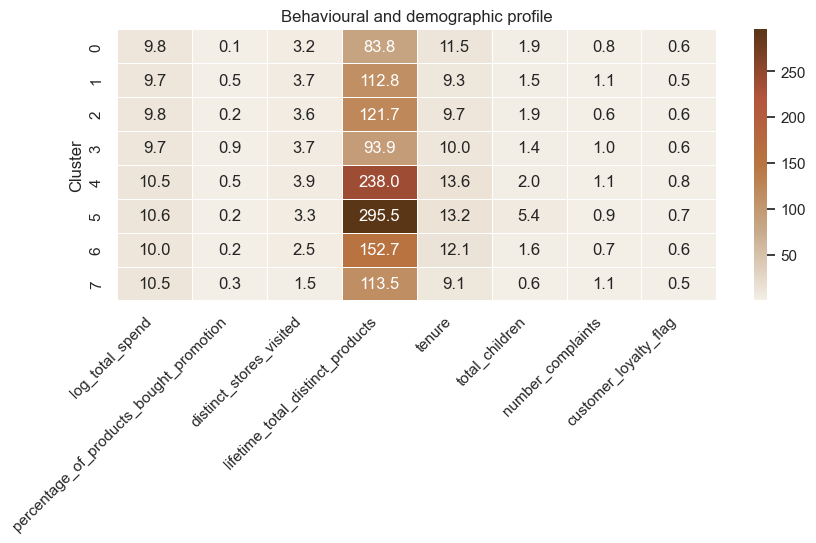

In [4]:
profile_cols = ucc.behavioural_profile_columns(df)
behaviour_profile = ucc.profile_table(df, profile_cols)
display(behaviour_profile)
ucc.plot_profile_heatmap(behaviour_profile, "Behavioural and demographic profile")

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>5) Loyalty, gender and household checks</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0;">These plots check whether the final clusters also differ in simple customer attributes that were useful in previous segmentation work.</p>
</div>

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:309: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.barplot(data=summary, x=cluster_col, y="share_%", hue="feature", palette=[MAIN_COLOR, SECONDARY_COLOR, NOTE_COLOR])


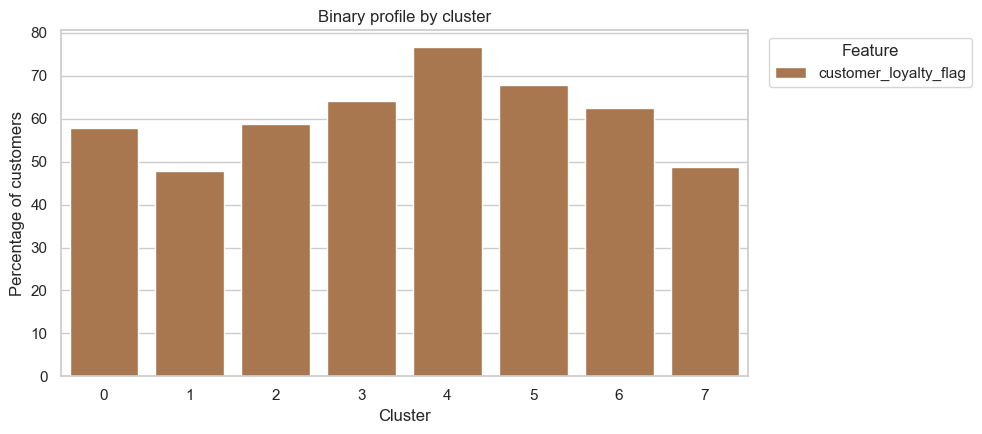

,cluster,feature,share_%
0,0,customer_loyalty_flag,57.8
1,1,customer_loyalty_flag,47.8
2,2,customer_loyalty_flag,58.7
3,3,customer_loyalty_flag,64.1
4,4,customer_loyalty_flag,76.8
5,5,customer_loyalty_flag,67.8
6,6,customer_loyalty_flag,62.5
7,7,customer_loyalty_flag,48.8


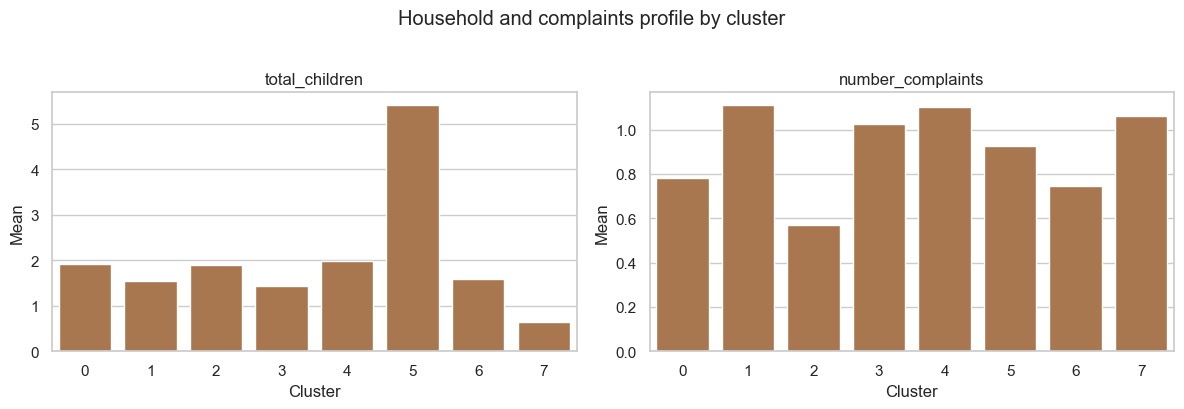

,cluster,total_children,number_complaints
0,0,1.92,0.78
1,1,1.54,1.11
2,2,1.89,0.57
3,3,1.43,1.03
4,4,1.99,1.10
5,5,5.41,0.92
6,6,1.59,0.74
7,7,0.64,1.06


In [5]:
binary_summary, household_summary = ucc.plot_simple_profile_checks(df)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>6) Normalised comparison</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Because the variables have different units, a min max scaled comparison is used to identify which clusters are highest or lowest on each feature.</p>
</div>

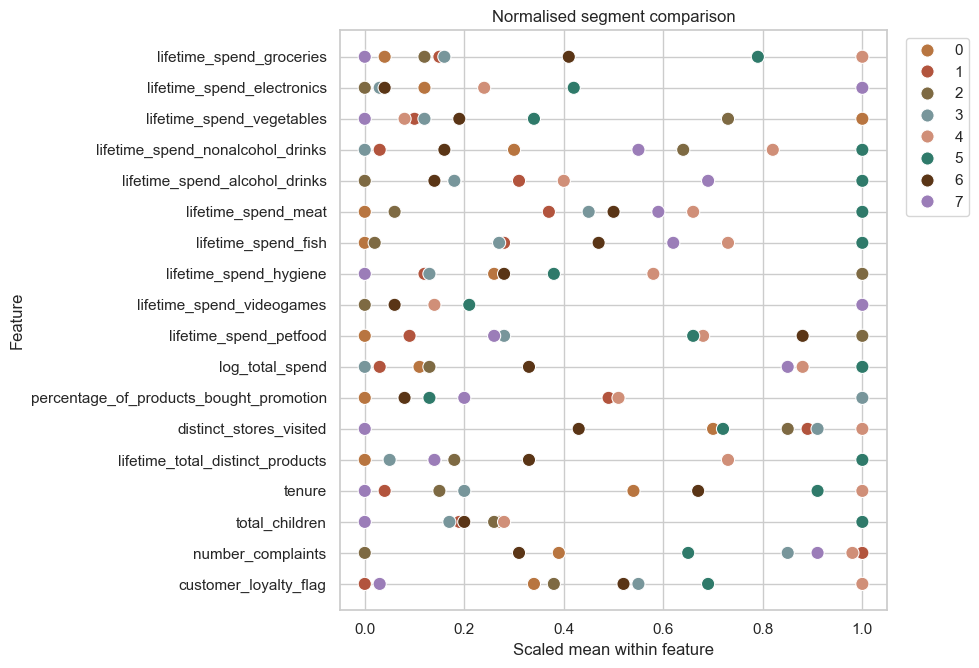

,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,tenure,total_children,number_complaints,customer_loyalty_flag
cluster,,,,,,,,,,,,,,,,,,
0,0.04,0.12,1.00,0.30,0.18,0.00,0.00,0.26,0.06,0.00,0.11,0.00,0.70,0.00,0.54,0.27,0.39,0.34
1,0.15,0.03,0.10,0.03,0.31,0.37,0.28,0.12,0.06,0.09,0.03,0.49,0.89,0.14,0.04,0.19,1.00,0.00
2,0.12,0.00,0.73,0.64,0.00,0.06,0.02,1.00,0.00,1.00,0.13,0.08,0.85,0.18,0.15,0.26,0.00,0.38
3,0.16,0.03,0.12,0.00,0.18,0.45,0.27,0.13,0.06,0.28,0.00,1.00,0.91,0.05,0.20,0.17,0.85,0.55
4,1.00,0.24,0.08,0.82,0.40,0.66,0.73,0.58,0.14,0.68,0.88,0.51,1.00,0.73,1.00,0.28,0.98,1.00
5,0.79,0.42,0.34,1.00,1.00,1.00,1.00,0.38,0.21,0.66,1.00,0.13,0.72,1.00,0.91,1.00,0.65,0.69
6,0.41,0.04,0.19,0.16,0.14,0.50,0.47,0.28,0.06,0.88,0.33,0.08,0.43,0.33,0.67,0.20,0.31,0.52
7,0.00,1.00,0.00,0.55,0.69,0.59,0.62,0.00,1.00,0.26,0.85,0.20,0.00,0.14,0.00,0.00,0.91,0.03


In [6]:
combined_profile = ucc.profile_table(df, spend_cols + profile_cols)
scaled_profile = ucc.plot_scaled_profile(combined_profile)
display(scaled_profile)

### 6.1 - Radar profile summary

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The radar plots give a compact view of the main profile of each segment. They use the same min max scaled profile as the normalised comparison above, but display one cluster at a time. This makes it easier to see whether a segment has a clear shape, for example promotion driven, technology focused, family oriented or wellness oriented.
<br><br>
Only a limited number of variables is used here so that the circular plots remain readable. The detailed interpretation still comes from the tables and feature by feature plots.
</div>

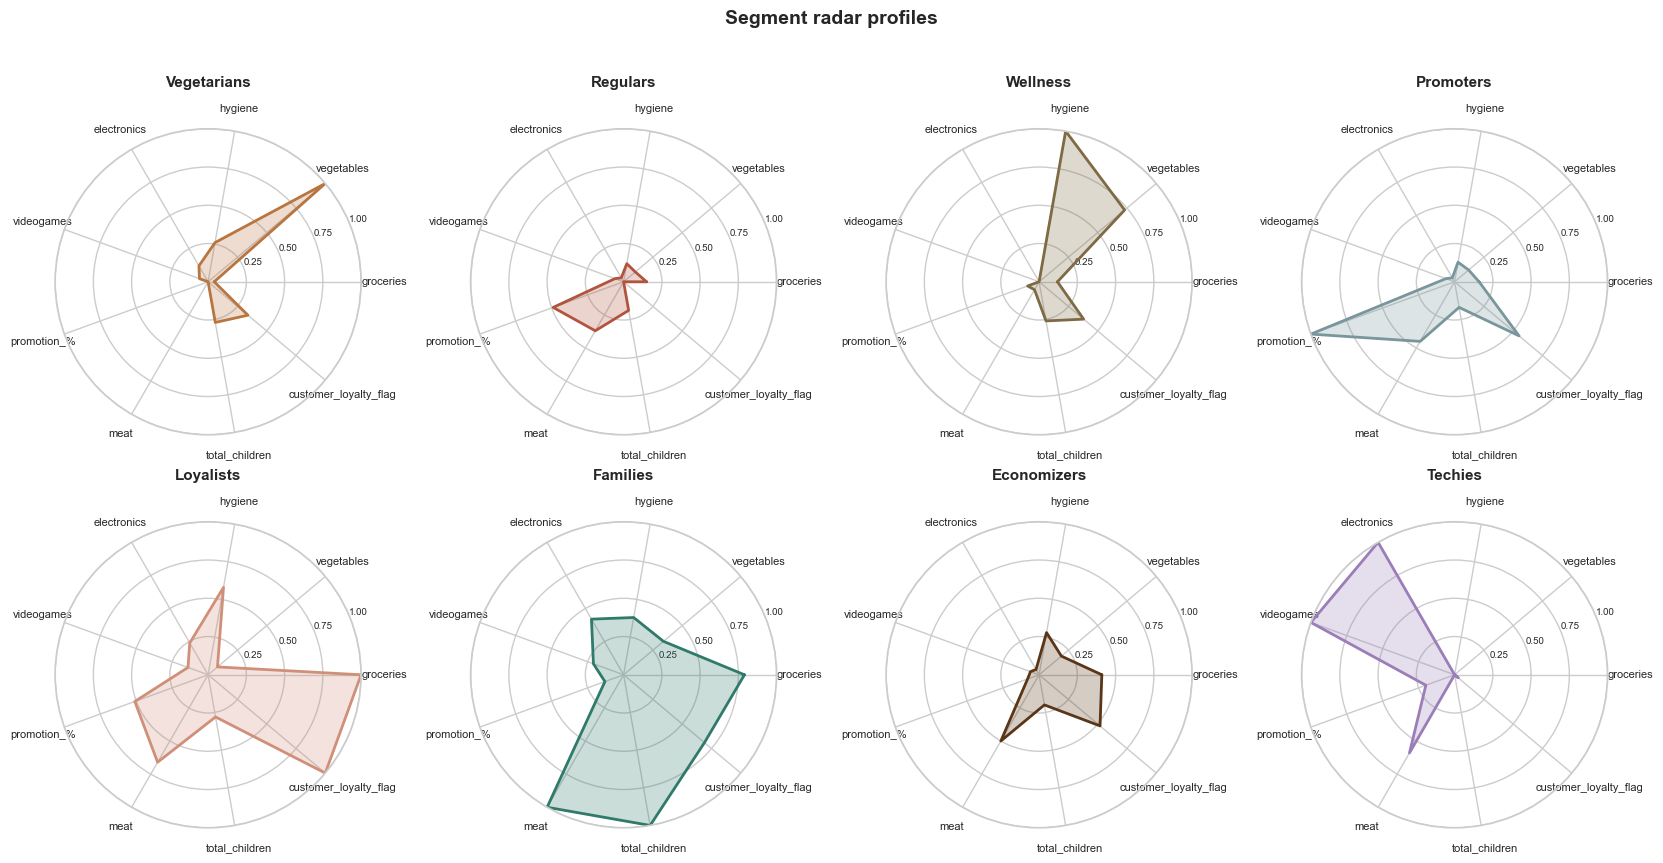

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_hygiene,lifetime_spend_electronics,lifetime_spend_videogames,percentage_of_products_bought_promotion,lifetime_spend_meat,total_children,customer_loyalty_flag
cluster,,,,,,,,,
0,0.04,1.00,0.26,0.12,0.06,0.00,0.00,0.27,0.34
1,0.15,0.10,0.12,0.03,0.06,0.49,0.37,0.19,0.00
2,0.12,0.73,1.00,0.00,0.00,0.08,0.06,0.26,0.38
3,0.16,0.12,0.13,0.03,0.06,1.00,0.45,0.17,0.55
4,1.00,0.08,0.58,0.24,0.14,0.51,0.66,0.28,1.00
5,0.79,0.34,0.38,0.42,0.21,0.13,1.00,1.00,0.69
6,0.41,0.19,0.28,0.04,0.06,0.08,0.50,0.20,0.52
7,0.00,0.00,0.00,1.00,1.00,0.20,0.59,0.00,0.03


In [7]:
radar_features = [
    "lifetime_spend_groceries",
    "lifetime_spend_vegetables",
    "lifetime_spend_hygiene",
    "lifetime_spend_electronics",
    "lifetime_spend_videogames",
    "percentage_of_products_bought_promotion",
    "lifetime_spend_meat",
    "total_children",
    "customer_loyalty_flag",
]

radar_profile = ucc.plot_radar_profiles(
    combined_profile,
    features=radar_features,
    cluster_names=ucc.CLUSTER_NAMES,
    title="Segment radar profiles",
)
display(radar_profile)


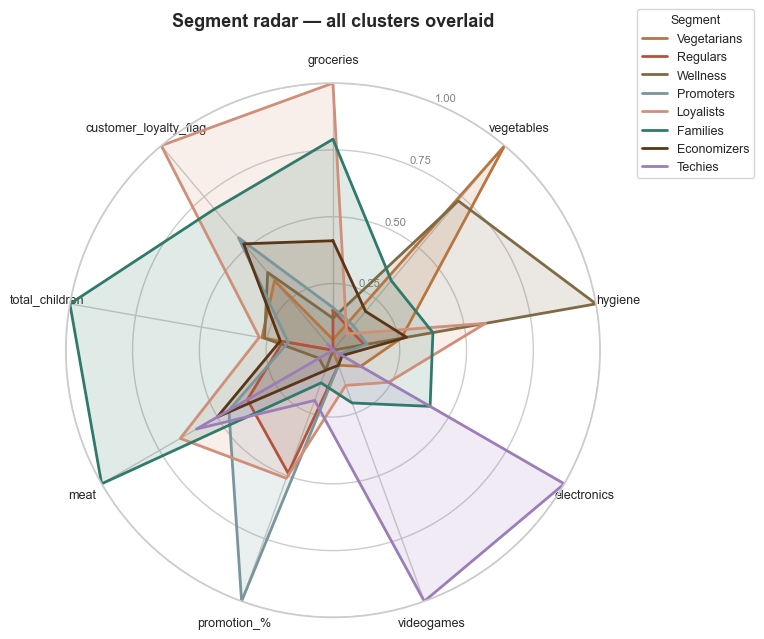

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_hygiene,lifetime_spend_electronics,lifetime_spend_videogames,percentage_of_products_bought_promotion,lifetime_spend_meat,total_children,customer_loyalty_flag
cluster,,,,,,,,,
0,0.04,1.00,0.26,0.12,0.06,0.00,0.00,0.27,0.34
1,0.15,0.10,0.12,0.03,0.06,0.49,0.37,0.19,0.00
2,0.12,0.73,1.00,0.00,0.00,0.08,0.06,0.26,0.38
3,0.16,0.12,0.13,0.03,0.06,1.00,0.45,0.17,0.55
4,1.00,0.08,0.58,0.24,0.14,0.51,0.66,0.28,1.00
5,0.79,0.34,0.38,0.42,0.21,0.13,1.00,1.00,0.69
6,0.41,0.19,0.28,0.04,0.06,0.08,0.50,0.20,0.52
7,0.00,0.00,0.00,1.00,1.00,0.20,0.59,0.00,0.03


In [8]:
ucc.plot_radar_combined(
    combined_profile,
    features=radar_features,
    cluster_names=ucc.CLUSTER_NAMES,
    title="Segment radar — all clusters overlaid",
)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>7) Feature by feature plots</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The barplots and boxplots check whether the differences observed in the profile tables are clear across the distribution or mainly driven by extreme values.</p>
</div>

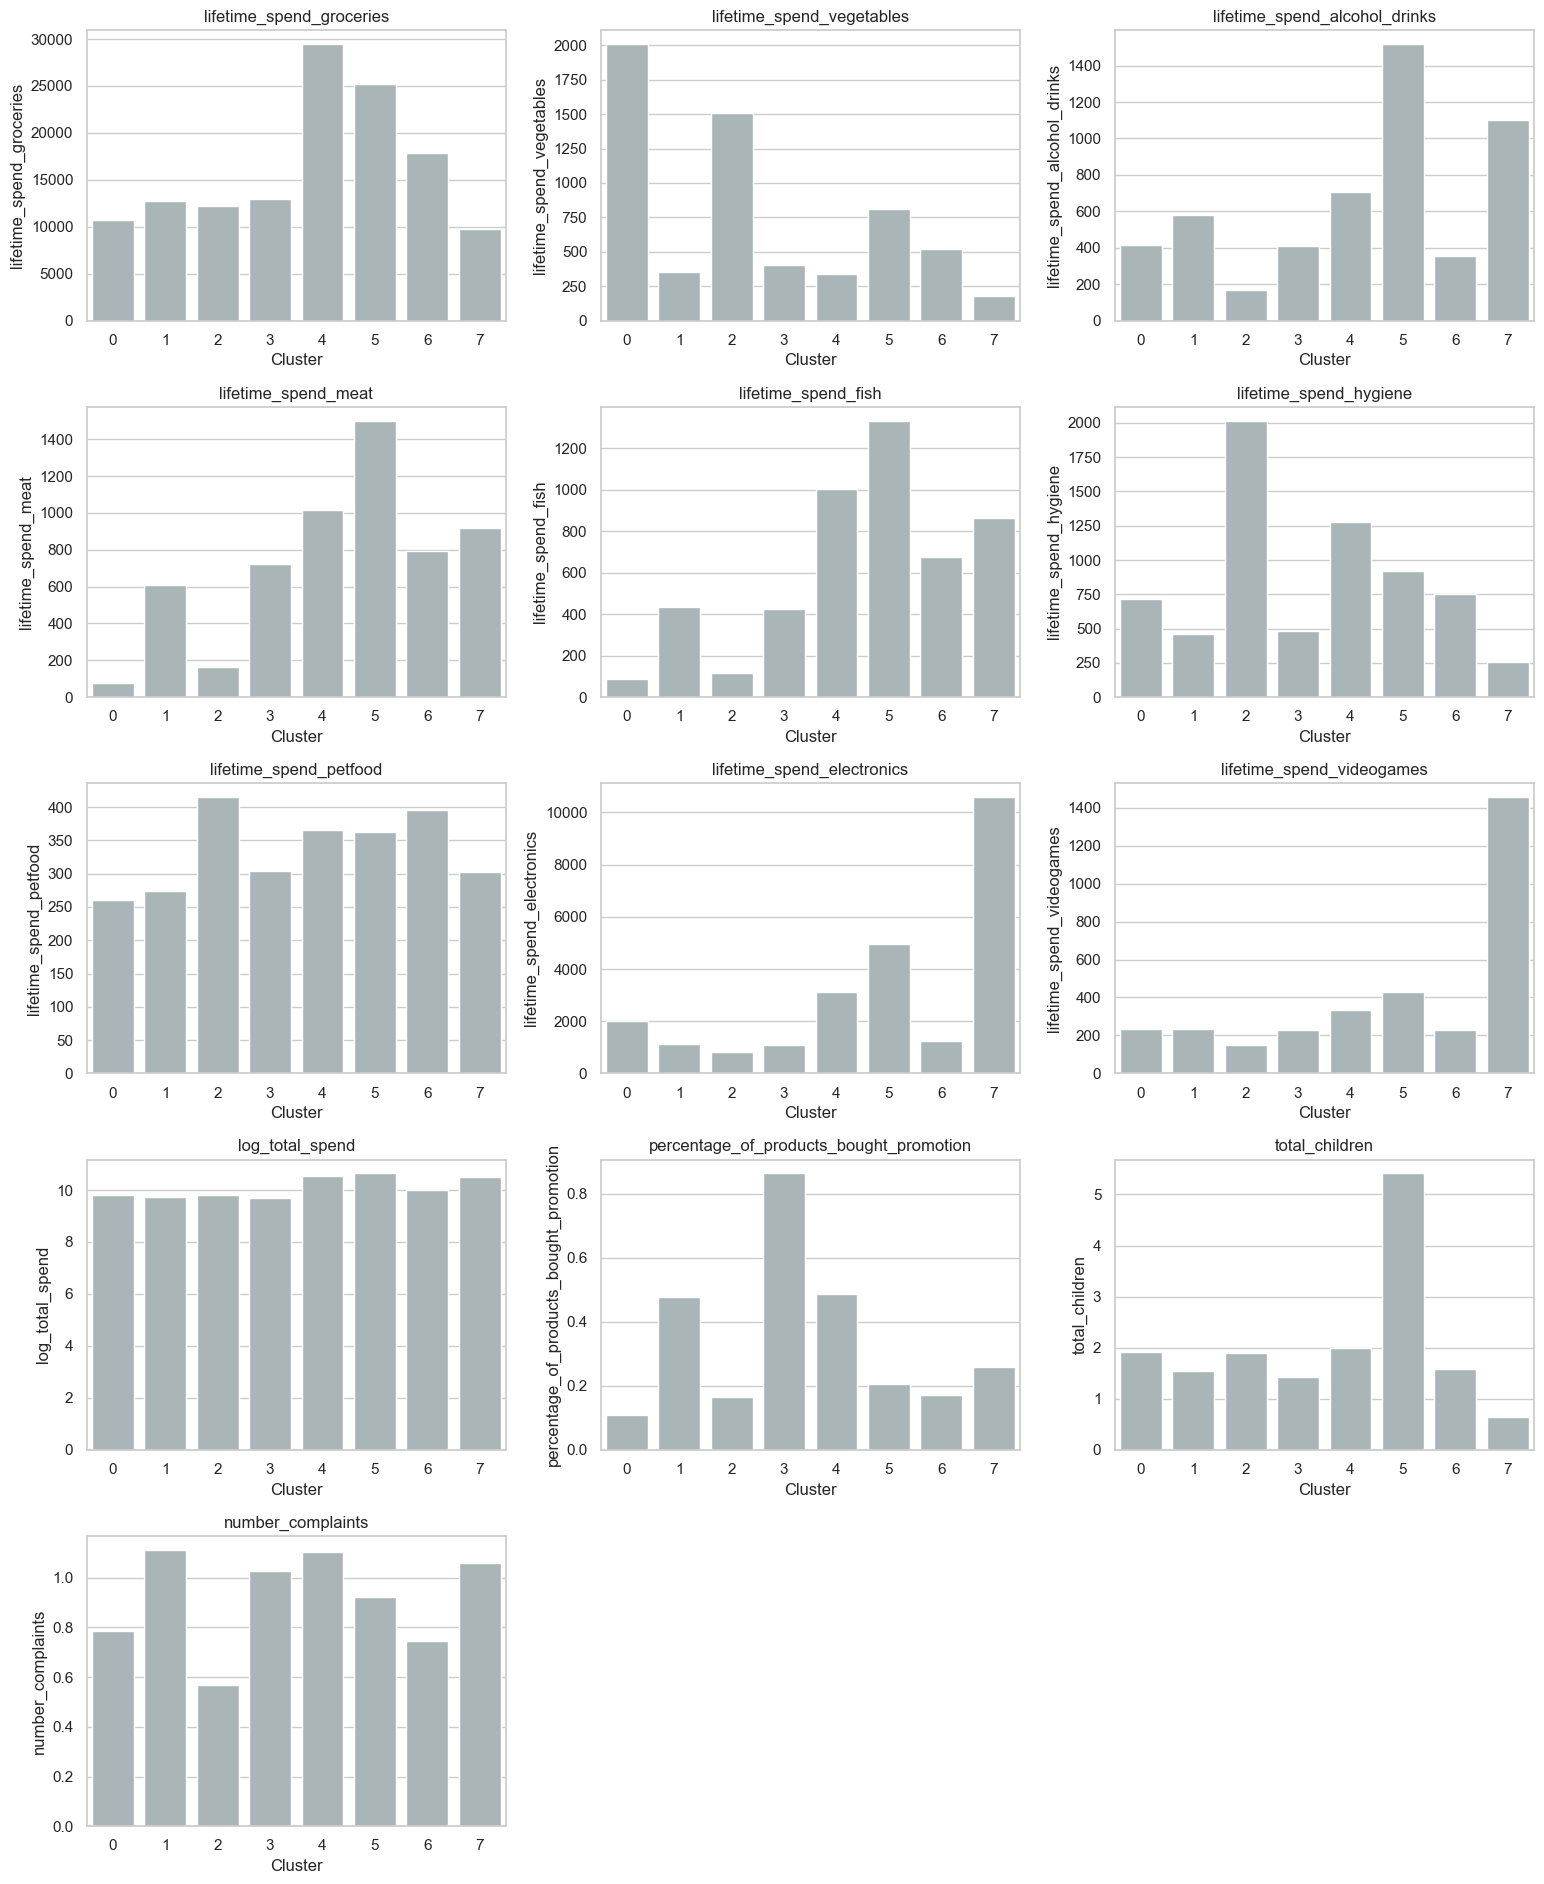

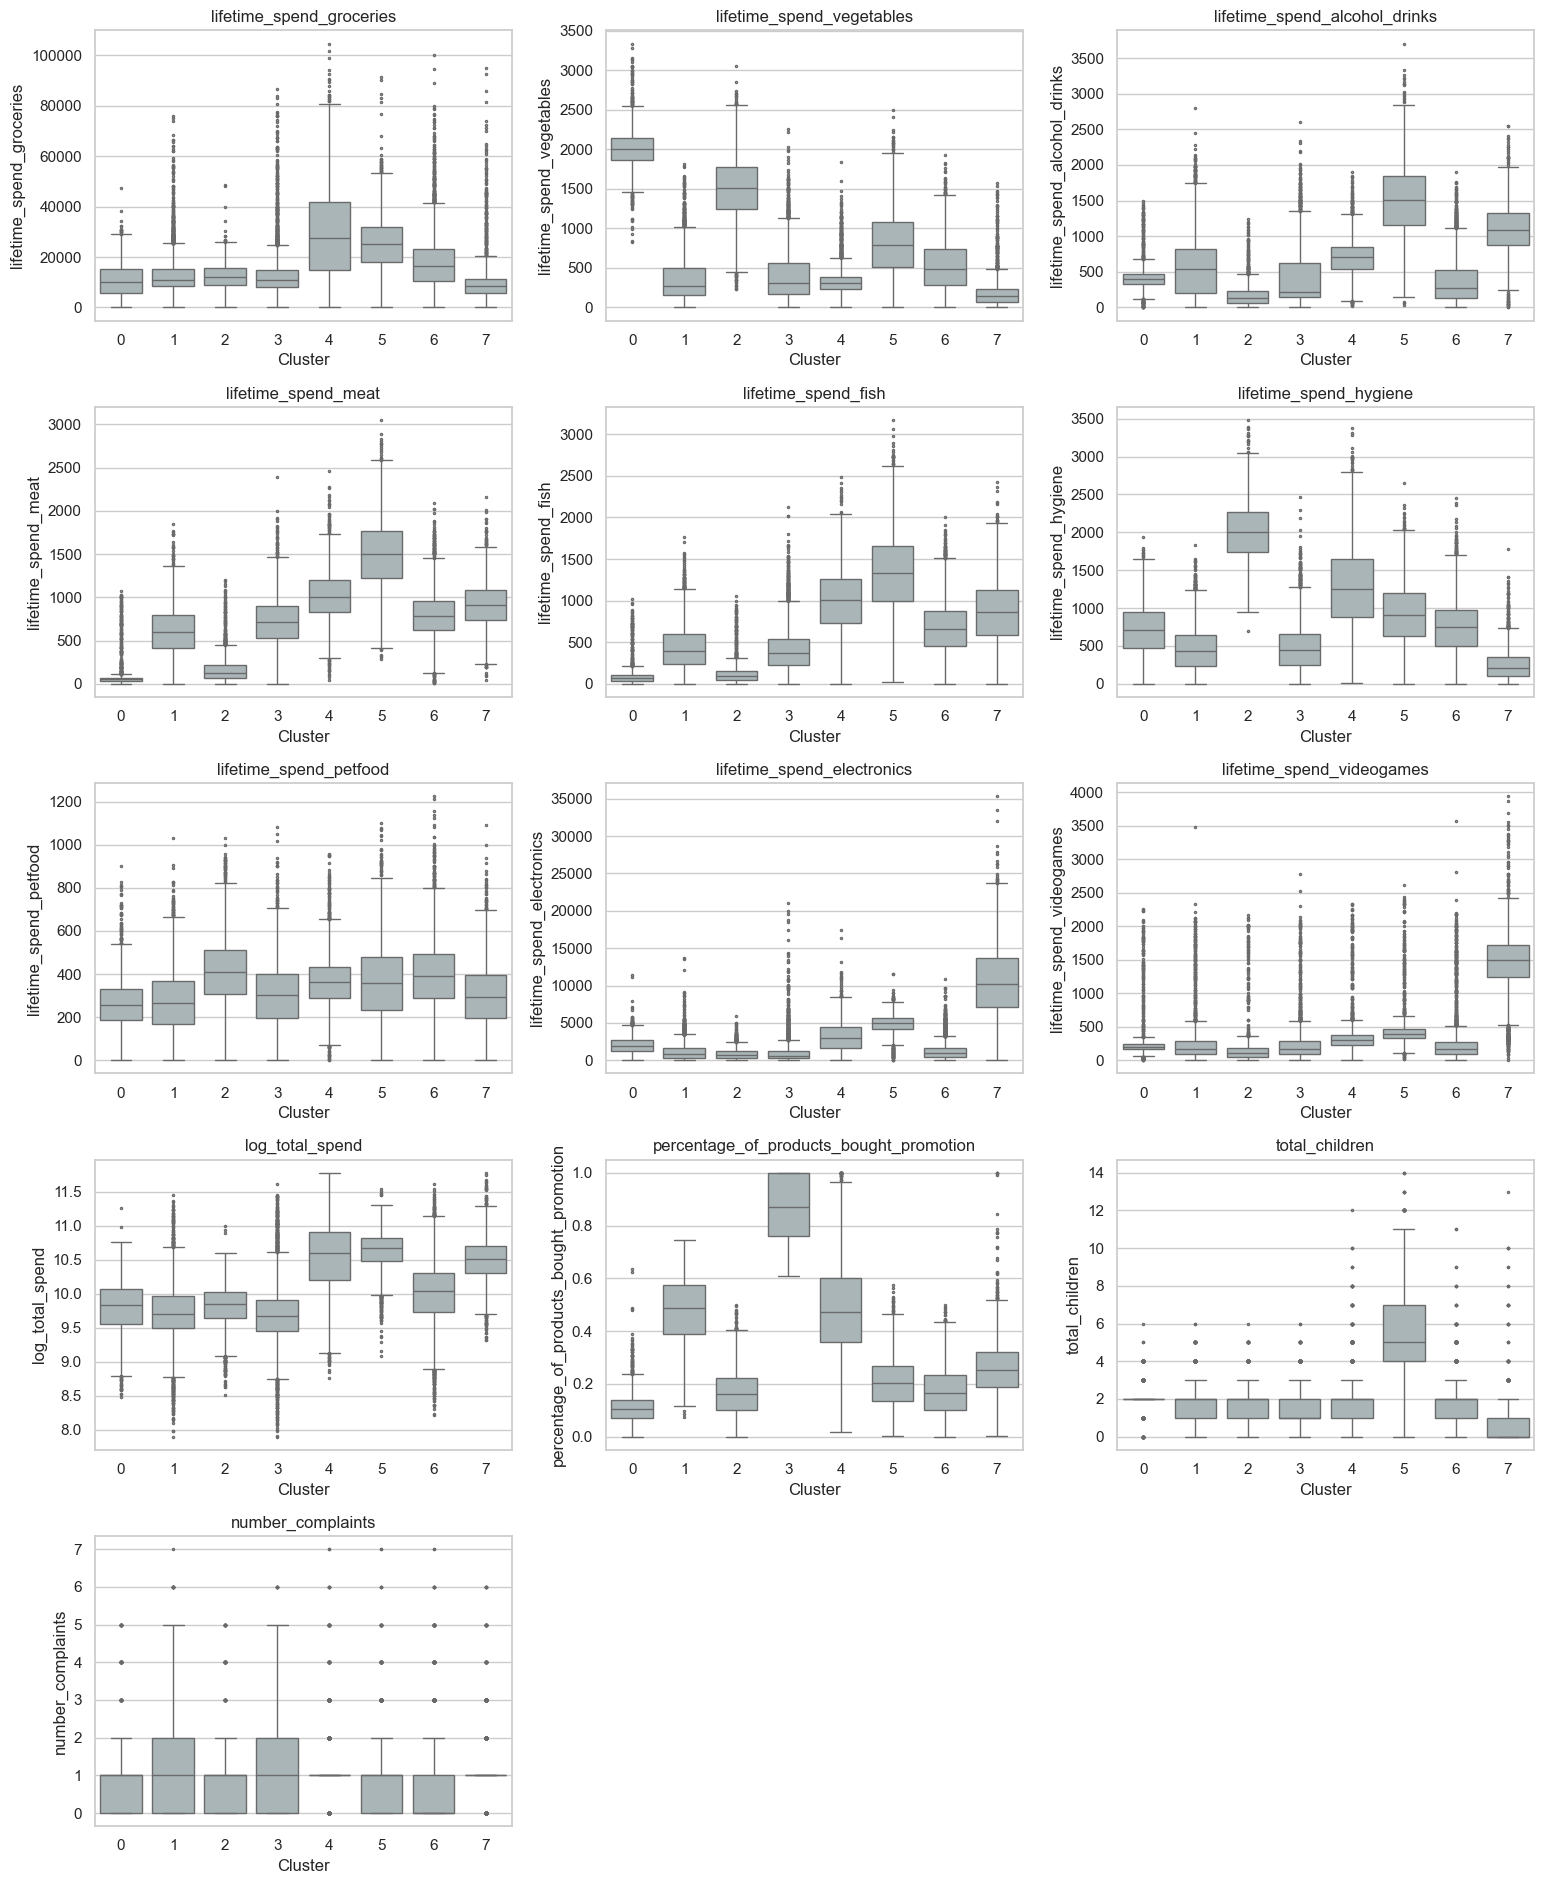

In [9]:
key_plot_cols = ucc.key_plot_columns(df)
ucc.plot_feature_bars(df, key_plot_cols)
ucc.plot_boxplot_grid(df, key_plot_cols)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>8) Main differentiators by cluster</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The following table lists the largest relative differences from the overall customer base. It is used as a compact evidence table for cluster naming.</p>
</div>

In [10]:
deviations = ucc.top_deviations(combined_profile, n=6)
display(deviations)


,cluster,feature,relative_difference_%,cluster_mean,overall_mean
0,0,lifetime_spend_vegetables,176.0,2007.66,727.34
1,0,lifetime_spend_meat,-89.8,73.78,723.87
2,0,lifetime_spend_fish,-85.4,88.59,608.12
3,0,percentage_of_products_bought_promotion,-68.6,0.11,0.35
4,0,lifetime_total_distinct_products,-43.7,83.83,148.91
5,0,lifetime_spend_videogames,-37.2,235.11,374.29
6,1,lifetime_spend_electronics,-58.7,1142.89,2764.28
7,1,lifetime_spend_vegetables,-51.0,356.64,727.34
8,1,lifetime_spend_nonalcohol_drinks,-44.2,259.13,464.35
9,1,lifetime_spend_hygiene,-44.0,459.10,820.55


### 6.2 - Cluster summary cards

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Each card shows three views of one segment: a spend radar on the left, the top deviations from the overall mean in the centre, and a stats summary on the right.
</div>

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:579: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


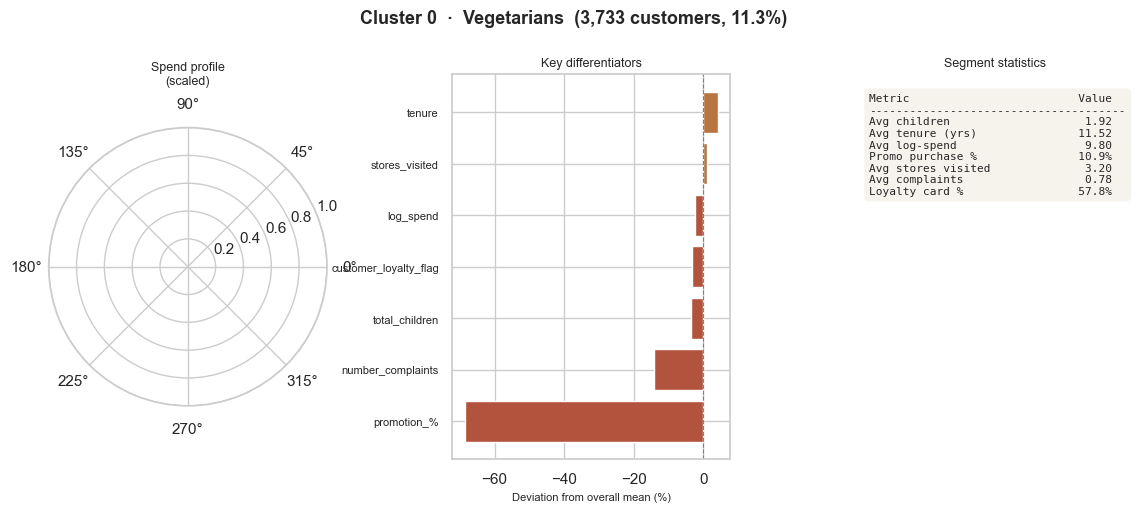

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:579: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


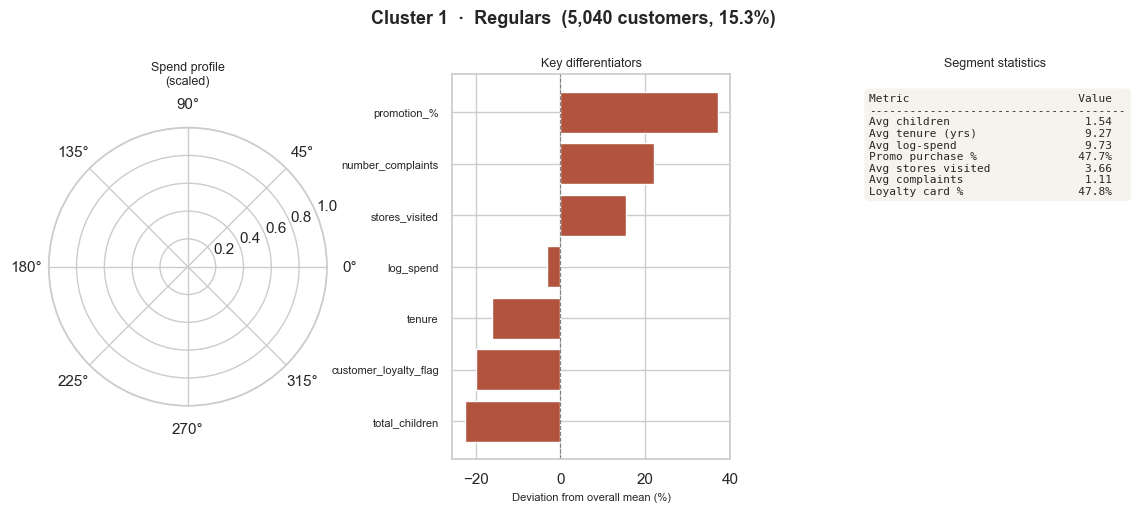

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:579: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


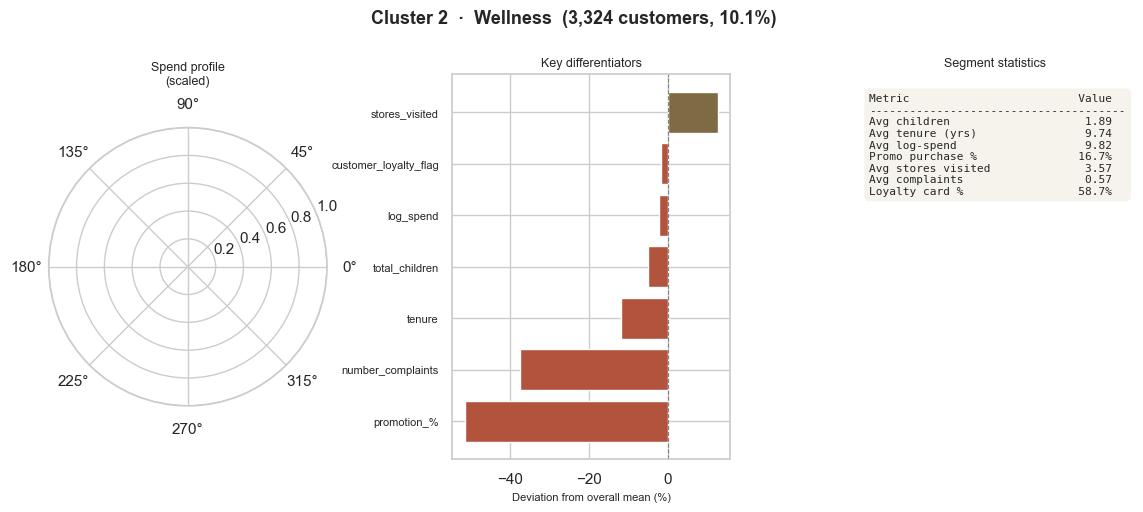

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:579: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


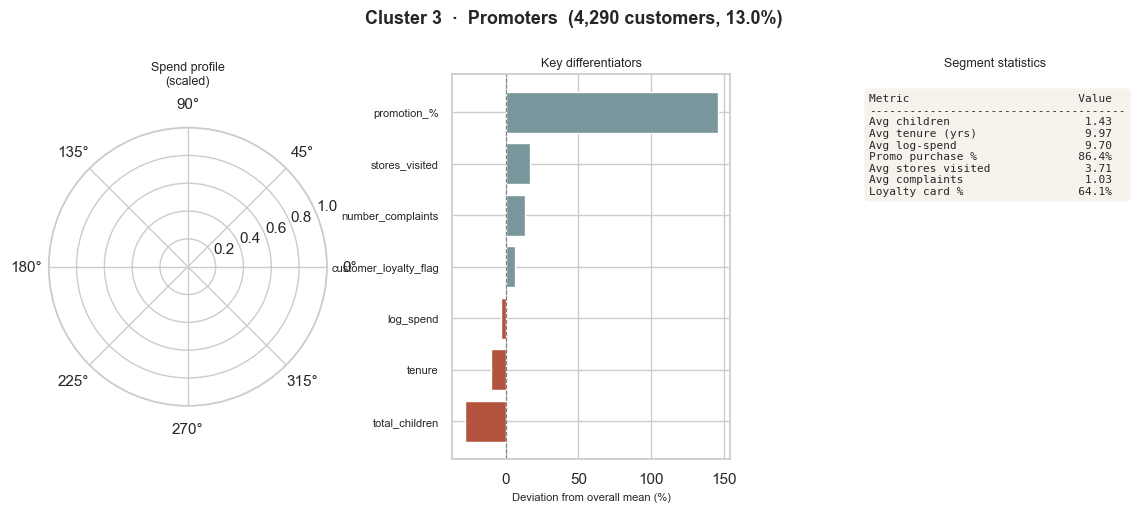

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:579: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


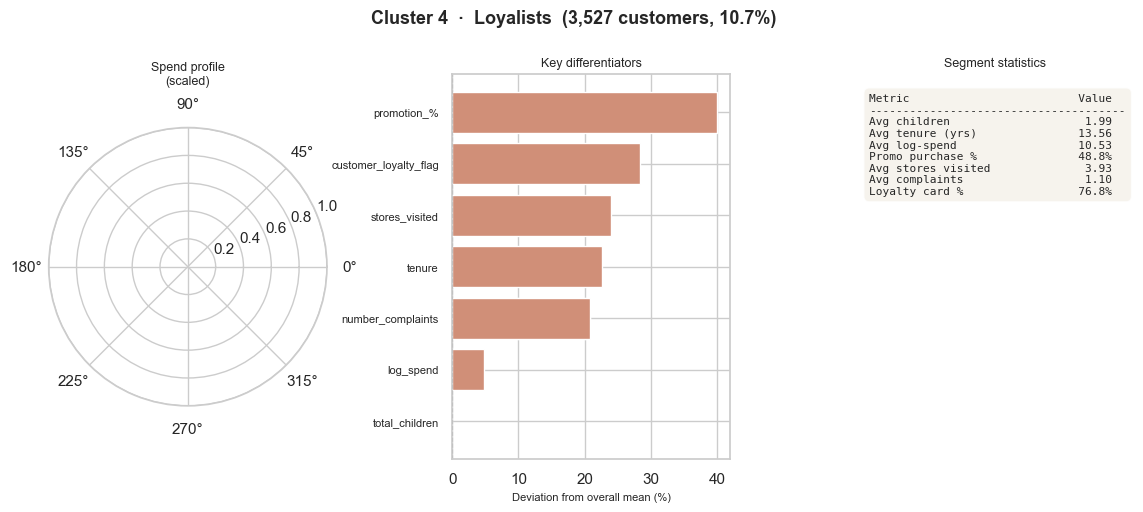

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:579: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


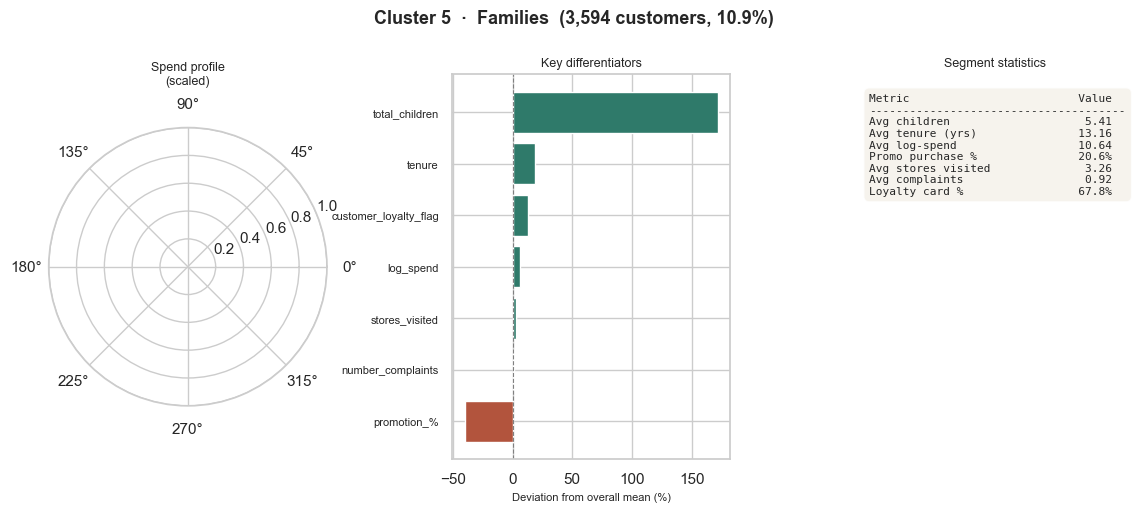

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:579: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


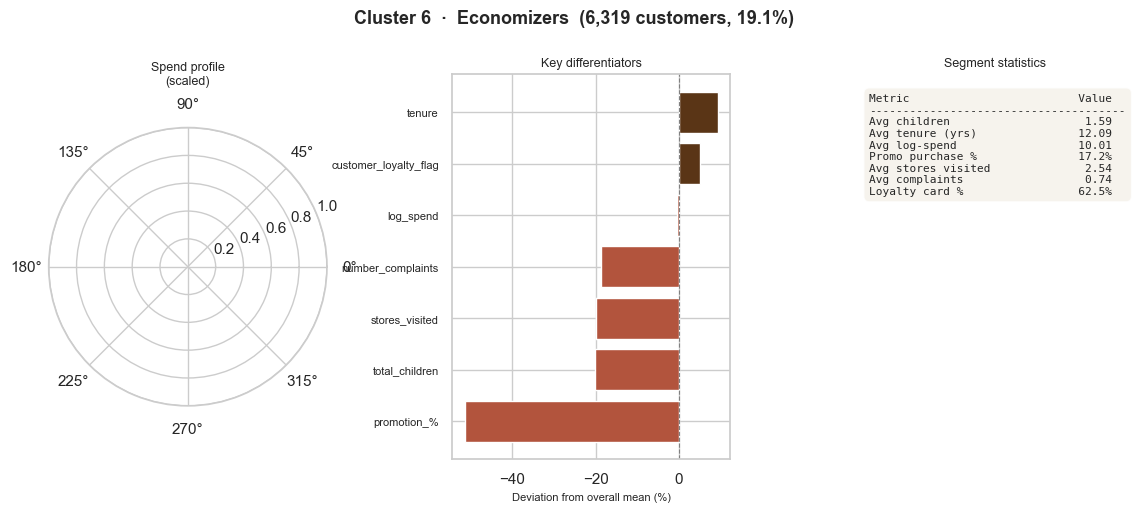

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:579: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


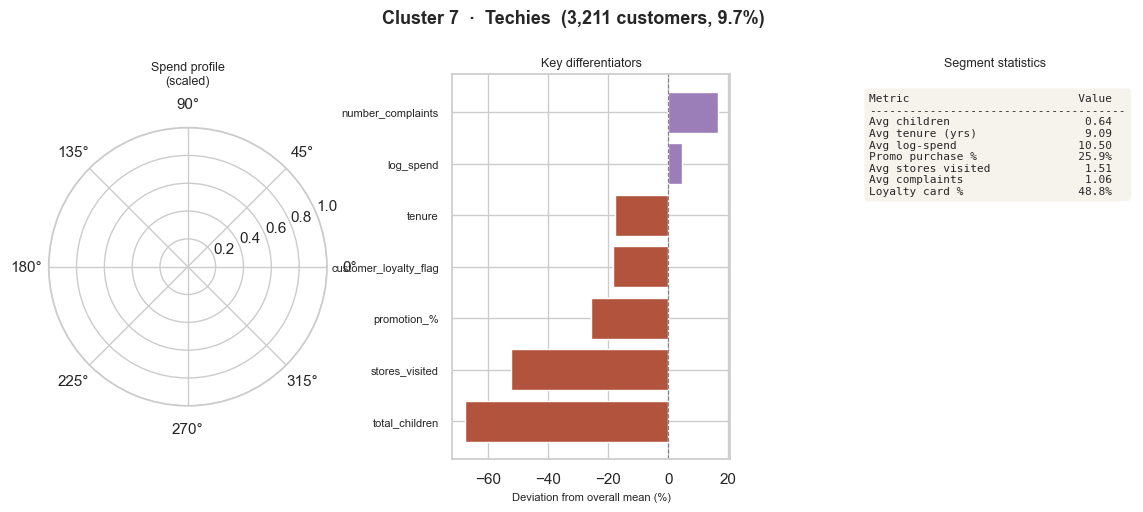

In [11]:
spend_features = [c for c in df.columns if c.startswith("annual_spend_")]

ucc.plot_all_cluster_cards(
    df,
    combined_profile,
    cluster_col="cluster",
    cluster_names=ucc.CLUSTER_NAMES,
    spend_features=spend_features,
)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>9) Cluster interpretation and naming rationale</b></h2>
<p style="color:#D8C0B4; margin:6px 0 14px 0;">
The final names are assigned after combining the normalised comparison, the deviation table and the original spend profiles. A cluster name is selected only when the same interpretation appears across several variables. This avoids naming a segment from one isolated feature and keeps the labels useful for business discussion.
</p>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>How the final names are chosen.</b><br><br>
The final name of each segment is chosen only when the same pattern appears in more than one view. For example, a customer group is not named after a product category just because one chart is high; the name must also be coherent with the deviation table, the original profile and the broader business interpretation.
</div>

<table style="width:100%; border-collapse:collapse; color:#F3EEE6; font-size:14px;">
<thead>
<tr style="border-bottom:1px solid #D8C0B4;">
<th style="text-align:left; padding:8px;">Cluster</th>
<th style="text-align:left; padding:8px;">Segment name</th>
<th style="text-align:left; padding:8px;">Main evidence</th>
<th style="text-align:left; padding:8px;">Interpretation</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>0</b></td><td style="padding:8px;"><b>Vegetarians</b></td><td style="padding:8px;">Highest vegetable spend, lowest meat spend among all segments, and low promotion use.</td><td style="padding:8px;">A clear plant-oriented basket profile, defined primarily by what customers buy and deliberately avoid.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>1</b></td><td style="padding:8px;"><b>Regulars</b></td><td style="padding:8px;">Moderate spend values across all categories, no single category dominating the profile, and medium promotion use.</td><td style="padding:8px;">A broad baseline customer group with no strongly distinctive behaviour. Useful as a reference against more specialised segments.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>2</b></td><td style="padding:8px;"><b>Wellness</b></td><td style="padding:8px;">Highest hygiene spend, high vegetable spend, low meat spend, and low promotion use.</td><td style="padding:8px;">Customers with a health and personal care oriented shopping pattern, combining vegetable and hygiene categories.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>3</b></td><td style="padding:8px;"><b>Promoters</b></td><td style="padding:8px;">Highest promotion purchase rate, low total spend, lower tenure and lower product diversity.</td><td style="padding:8px;">A price-sensitive segment where promotional purchases are the strongest behavioural signal.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>4</b></td><td style="padding:8px;"><b>Loyalists</b></td><td style="padding:8px;">Highest grocery spend, highest loyalty flag rate, longest tenure and highest total spend.</td><td style="padding:8px;">Established high-value customers with a long relationship with the retailer and strong grocery-driven basket behaviour.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>5</b></td><td style="padding:8px;"><b>Families</b></td><td style="padding:8px;">Highest number of children, highest meat spend, and very high total spend across several categories.</td><td style="padding:8px;">Large households with broad stock-up needs and high basket value across food categories.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>6</b></td><td style="padding:8px;"><b>Economizers</b></td><td style="padding:8px;">Fewest distinct stores visited among all segments, moderate total spend and low promotion use.</td><td style="padding:8px;">Customers with a narrow shopping routine, concentrated in few stores and with limited basket diversification.</td></tr>
<tr><td style="padding:8px;"><b>7</b></td><td style="padding:8px;"><b>Techies</b></td><td style="padding:8px;">Highest electronics and videogame spend, fewest stores visited after Economizers, and smallest household size.</td><td style="padding:8px;">Specialised customers dominated by technology and entertainment purchases, with a distinctly different basket from all other segments.</td></tr>
</tbody>
</table>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why there is no final Pets segment.</b><br><br>
A pet oriented alternative was tested in the clustering notebook. It produced a readable pet segment, but the global structure was slightly weaker and the final UMAP was less clean. The final naming therefore keeps petfood as a profiling insight rather than forcing it into the final segmentation. This decision favours a more stable eight cluster solution.
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>10) Geographic check</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Latitude and longitude are used only for profiling. This plot checks whether any final segment is associated with a specific geographic concentration.</p>
</div>

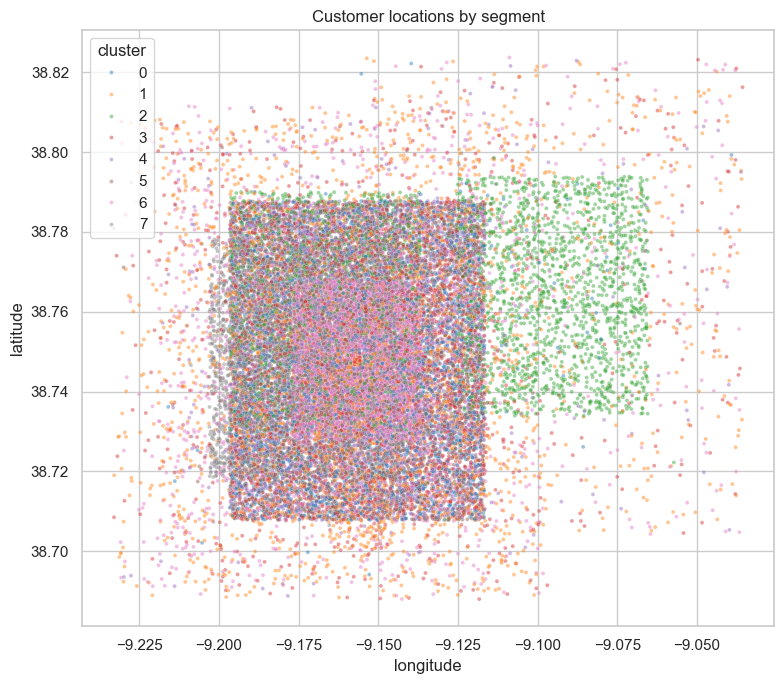

In [12]:
if {"latitude", "longitude"}.issubset(df.columns):
    plt.figure(figsize=(8, 7))
    sns.scatterplot(data=df, x="longitude", y="latitude", hue="cluster", palette="tab10", s=8, alpha=0.45)
    plt.title("Customer locations by segment")
    plt.tight_layout()
    plt.show()


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>11) Final segment names</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final names are assigned after reviewing the full profile of each cluster. The clustering distance uses selected purchase and promotion variables, while groceries, demographics, loyalty, household structure and complaints support interpretation. Petfood was reviewed during modelling, but it was not strong enough to replace the cleaner final solution.</p>
</div>


In [13]:
display(
    df[["cluster", "cluster_name"]]
    .drop_duplicates()
    .sort_values("cluster")
    .reset_index(drop=True)
)


,cluster,cluster_name
0,0,Vegetarians
1,1,Regulars
2,2,Wellness
3,3,Promoters
4,4,Loyalists
5,5,Families
6,6,Economizers
7,7,Techies


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>12) Export ID and cluster mapping</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final export keeps one row per customer with the numerical cluster and the corresponding business name. This file is the bridge between the modelling stage and any later business analysis, such as basket analysis or segment based recommendations.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why the mapping is exported.</b><br><br>
The modelling notebook exports numeric cluster labels because they are easier to reproduce and validate. This notebook adds the business names after the characterization step, creating a clean bridge between the technical segmentation and the final business interpretation.
</div>

In [14]:
id_cluster = ucc.export_id_cluster(df, f"{DATA_DIR}/id_and_cluster.csv")
print("Exported rows:", len(id_cluster))
id_cluster.head()


Exported rows: 33038


,customer_id,cluster,cluster_name
0,3,1,Regulars
1,4,2,Wellness
2,5,6,Economizers
3,7,7,Techies
4,8,7,Techies
